In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data Summerization

In [18]:
dfTrain = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/train.csv')
dfTest = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/test.csv')


In [19]:
dfTrain.head(10)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
5,5,38,1,4,138,283,0,0,147,1,1.6,2,2,7,Presence
6,6,59,1,4,130,246,0,2,152,0,0.8,2,2,3,Presence
7,7,60,0,3,120,245,0,0,151,0,1.2,1,0,3,Absence
8,8,48,0,4,140,212,0,2,125,0,0.0,1,0,3,Absence
9,9,44,0,4,150,197,0,0,150,0,0.0,2,0,3,Absence


In [20]:
dfTrain.shape


(630000, 15)

In [21]:
dfTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [8]:
dfTrain.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


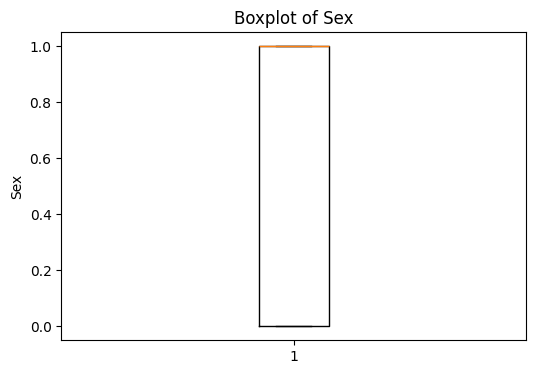

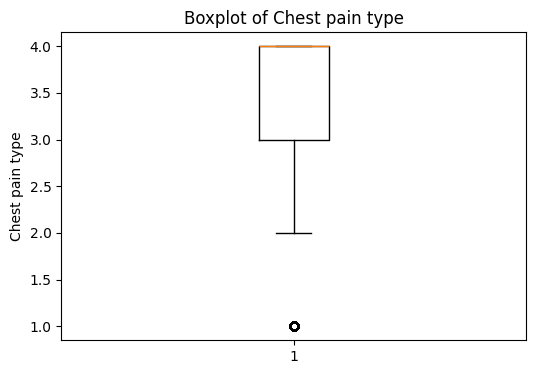

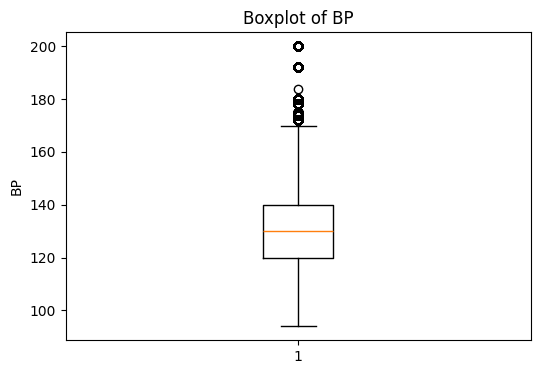

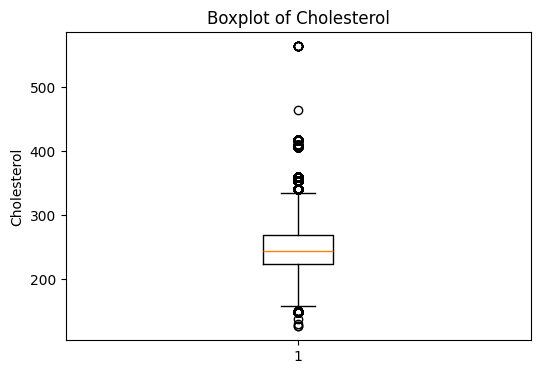

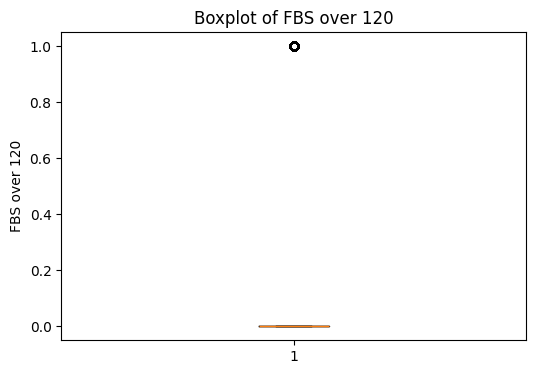

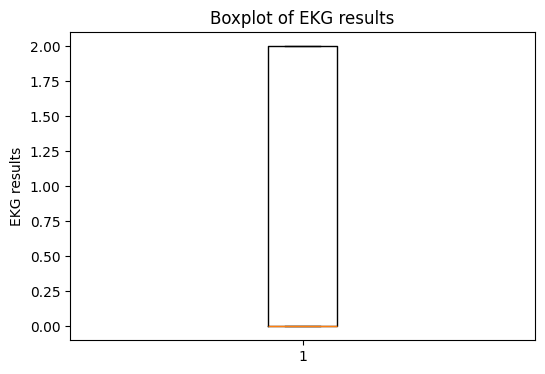

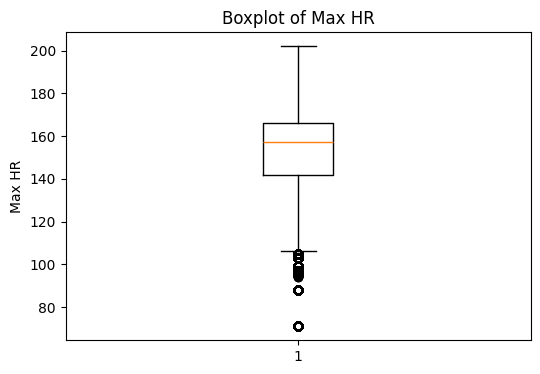

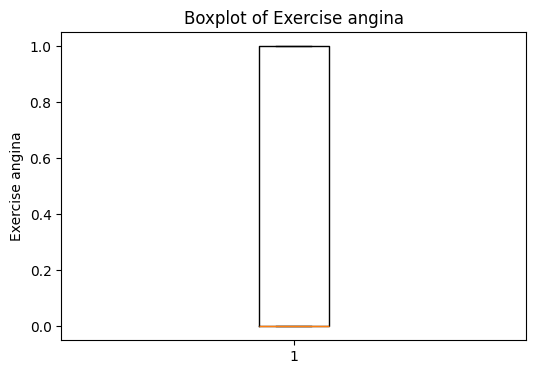

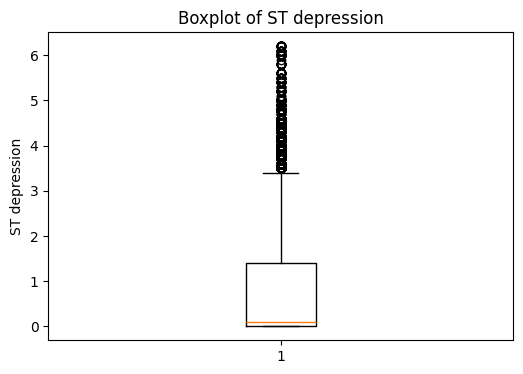

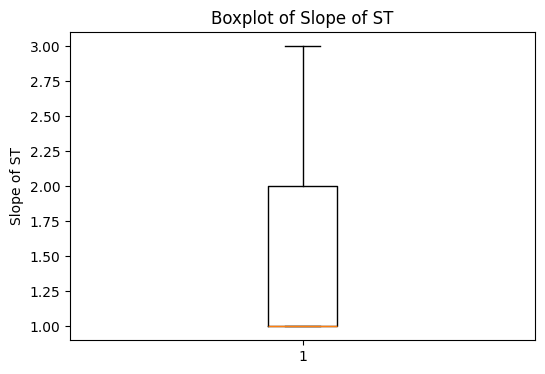

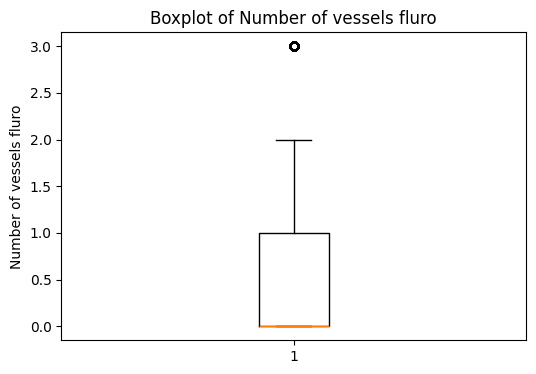

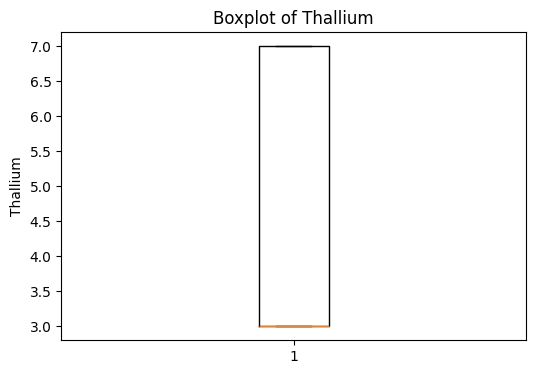

In [22]:
import matplotlib.pyplot as plt

# Exclude 'id' and select numeric features
numeric_features = dfTrain.drop(columns=['id','Age'],axis = 1).select_dtypes(include='number').columns

# Loop over each feature and plot
for col in numeric_features:
    plt.figure(figsize=(6, 4))         # smaller figure per feature
    plt.boxplot(dfTrain[col], vert=True)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

Here we check for outliers. And in this step we detect some outliers in continues numerical features.

In [23]:

outlier_summary = []

for col in numeric_features:
    Q1 = dfTrain[col].quantile(0.25)
    Q3 = dfTrain[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = dfTrain[(dfTrain[col] < lower_bound) | (dfTrain[col] > upper_bound)]
    count = outliers.shape[0]
    percent = (count / dfTrain.shape[0]) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': count,
        'Outlier %': percent
    })

# Convert to DataFrame for easy viewing
outlier_df = pd.DataFrame(outlier_summary).sort_values(by='Outlier %', ascending=False)
print(outlier_df)

                    Feature  Outlier Count  Outlier %
4              FBS over 120          50392   7.998730
1           Chest pain type          28602   4.540000
10  Number of vessels fluro          22857   3.628095
6                    Max HR          14246   2.261270
8             ST depression           9971   1.582698
2                        BP           9011   1.430317
3               Cholesterol           2194   0.348254
0                       Sex              0   0.000000
7           Exercise angina              0   0.000000
5               EKG results              0   0.000000
9               Slope of ST              0   0.000000
11                 Thallium              0   0.000000


In [24]:
print(dfTrain['FBS over 120'].unique())
print(dfTrain['Chest pain type'].unique())
print(dfTrain['Number of vessels fluro'].unique())

[0 1]
[4 1 2 3]
[2 0 3 1]


In [25]:
outlier_features = ['Max HR', 'ST depression', 'BP', 'Cholesterol']

mask = np.ones(dfTrain.shape[0], dtype=bool)

for col in outlier_features:
    Q1 = dfTrain[col].quantile(0.25)
    Q3 = dfTrain[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    mask &= (dfTrain[col] >= lower_bound) & (dfTrain[col] <= upper_bound)


dfTrainClean = dfTrain[mask]
print(dfTrainClean.shape)

(595443, 15)


## Feature Engineering

In [26]:
mapping = {'Presence' : 1, 'Absence' : 0}
dfTrain['target'] = dfTrain['Heart Disease'].map(mapping)


In [27]:
dfTrain['Cholesterol_BP_Ratio'] = dfTrain['Cholesterol'] / dfTrain['BP']
dfTrain['Cholesterol_Age_Ratio'] = dfTrain['Cholesterol'] / dfTrain['Age']
dfTrain['BP_Age_Ratio'] = dfTrain['BP'] / dfTrain['Age']
dfTrain['Exercise angina_Max HR'] = dfTrain['Exercise angina'] * dfTrain['Max HR']
dfTrain['Exercise angina_ST depression'] = dfTrain['Exercise angina'] * dfTrain['ST depression']



In [ ]:
# Separate target and features
yTrain = dfTrainClean['target']
xTrain = dfTrainClean.drop(columns=['id', 'target'])

In [ ]:
from sklearn.feature_selection import mutual_info_classif

miscores = mutual_info_classif(xTrain, yTrain, random_state = 42)
mi_series = pd.Series(miscores, index=xTrain.columns)

for feature, score in mi_series.items():
    print(f"{feature}: {score:.4f}")